In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [83]:
df=pd.read_csv("Iris.csv")


In [84]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

[]

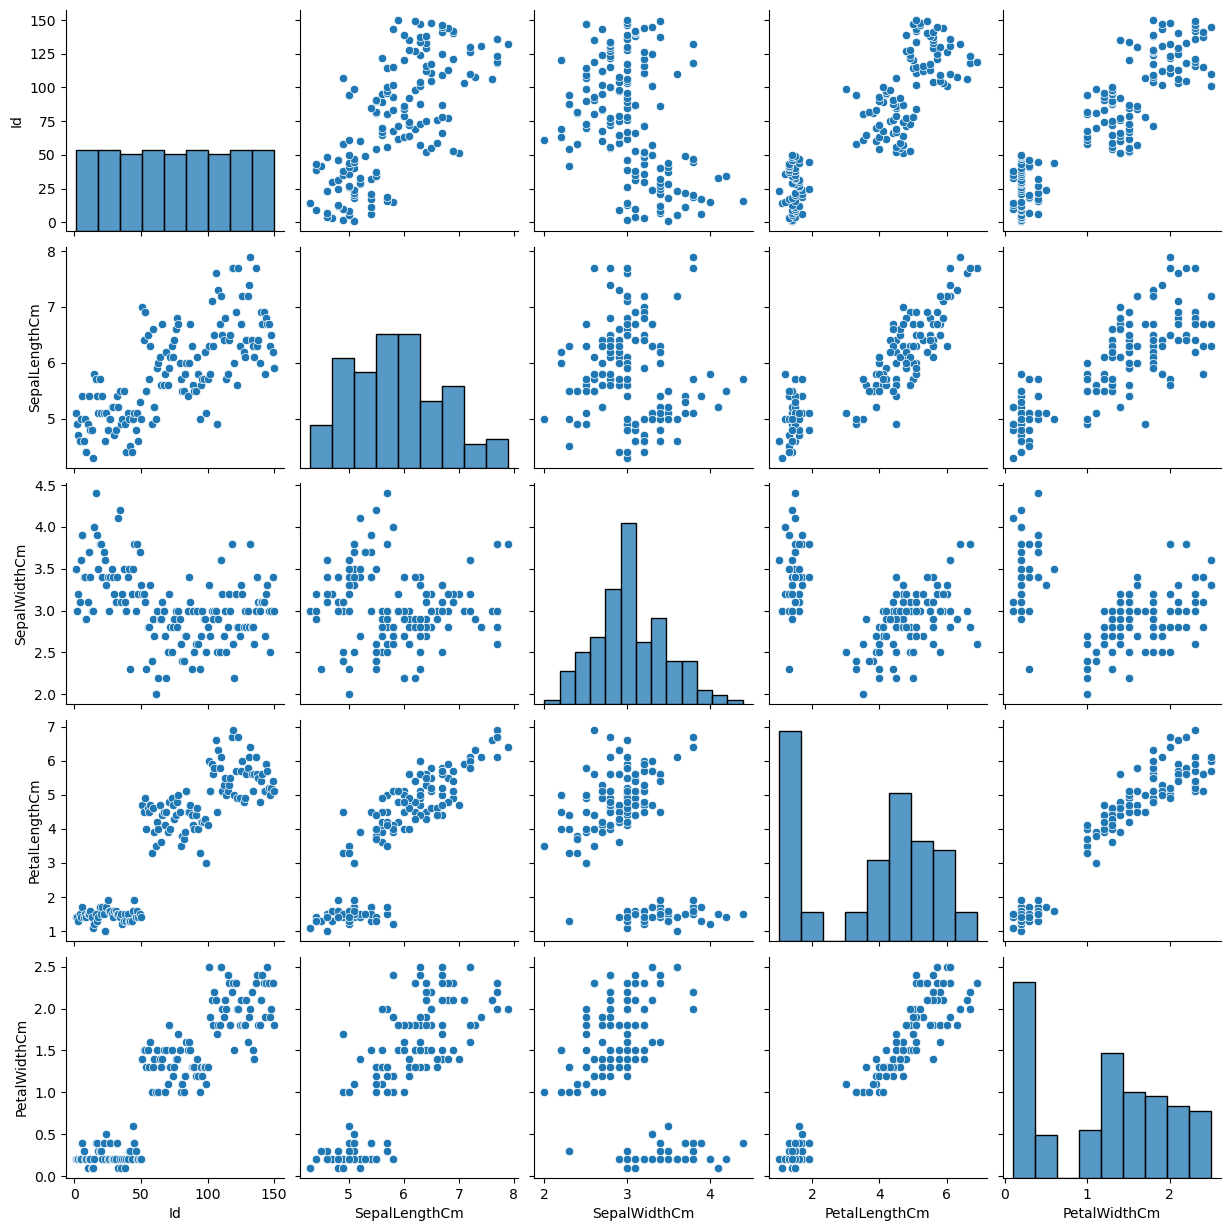

In [85]:
sns.pairplot(df)
plt.plot()

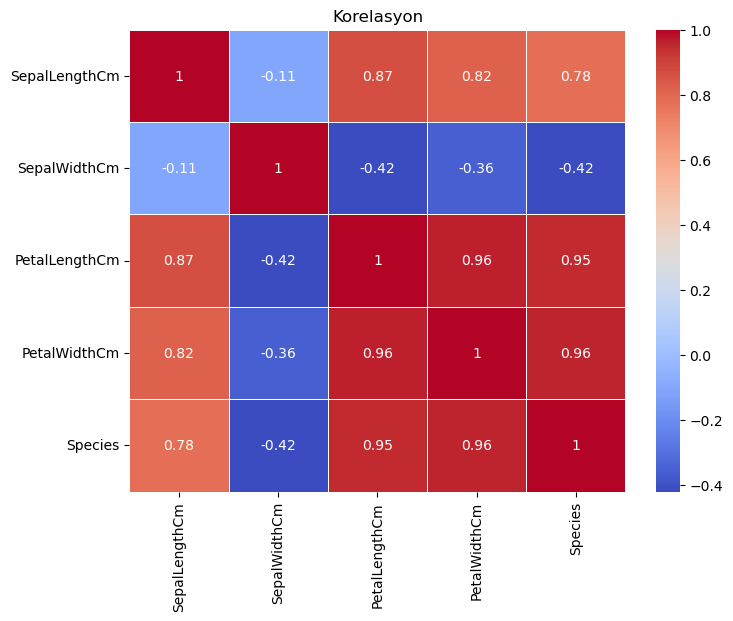

In [153]:
corr=df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("Korelasyon")
plt.show()

In [ ]:
# Korelasyon hesaplama
corr_matrix = df.corr()

# Haritayı çizme
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title('Korelasyon Haritası')
plt.show()

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [87]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [88]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [89]:
df=df.drop("Id",axis=1)

In [90]:
from sklearn.preprocessing import LabelEncoder

In [91]:
label_encoder=LabelEncoder()
df["Species"]=label_encoder.fit_transform(df["Species"])

In [92]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [93]:
df["Species"].unique()

array([0, 1, 2])

In [94]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [95]:
X=df.drop("Species",axis=1)
y=df["Species"]

In [96]:
from sklearn.model_selection import train_test_split

In [97]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [98]:
from sklearn.preprocessing import StandardScaler

In [99]:
scaler=StandardScaler()
X_train_scaler=scaler.fit_transform(X_train)
X_test_scaler=scaler=scaler.transform(X_test)

In [100]:
from sklearn.naive_bayes import GaussianNB

In [101]:
gnb=GaussianNB()

In [102]:
gnb.fit(X_train_scaler,y_train)
y_pred=gnb.predict(X_test_scaler)

In [110]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [116]:
print("confusion_matrix ",confusion_matrix(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("classification_report", classification_report(y_test,y_pred))

confusion_matrix  [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy_score 1.0
classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [112]:
from sklearn.linear_model import LogisticRegression

In [118]:
logistic=LogisticRegression()

In [123]:
logistic.fit(X_train_scaler,y_train)
y_pred2=logistic.predict(X_test_scaler)
print("confusion_matrix :",confusion_matrix(y_test,y_pred2))
print("accuracy_score : ",accuracy_score(y_test,y_pred2))
print("classification_report : ",classification_report(y_test,y_pred2))

confusion_matrix : [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy_score :  1.0
classification_report :                precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [127]:
from sklearn.svm import SVC

In [137]:
svc=SVC(kernel="rbf")
svc.fit(X_train_scaler,y_train)
y_pred3=svc.predict(X_test_scaler)
print("confusion_matrix ",confusion_matrix(y_test,y_pred2))
print("accuracy_score",accuracy_score(y_test,y_pred2))
print("classification_report",classification_report(y_test,y_pred2))

confusion_matrix  [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy_score 1.0
classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [140]:
svc=SVC(kernel="linear")
svc.fit(X_train_scaler,y_train)
y_pred3=svc.predict(X_test_scaler)
print("confusion_matrix",confusion_matrix(y_test,y_pred3))
print("accuracy_score",accuracy_score(y_test,y_pred3))
print("classification_report",classification_report(y_test,y_pred3))

confusion_matrix [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy_score 1.0
classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

